In [79]:
# Importing all libraries

#Basic libraries
import numpy as np
import pandas as pd
import seaborn as sb
import warnings
import matplotlib.pyplot as plt

#for skewness
from scipy.stats import skew

#for encoding
from sklearn.preprocessing import LabelEncoder

#for train and test
from sklearn.model_selection import train_test_split

#for model training
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# importing the file
insur_dataset = pd.read_csv('car_insur.csv')

In [3]:
insur_dataset.shape

(30000, 24)

In [4]:
insur_dataset

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,13/06/2024,...,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,23/03/2025,...,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,26/01/2025,...,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,03/06/2024,...,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,21/05/2024,...,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,POL129995,NY,200,973.40,47,FEMALE,Masters,Lawyer,paintball,04/04/2025,...,IL,West Natashaside,5,3,1,1,No,10502.67,16070.08,N
29996,POL129996,CA,300,869.67,38,MALE,Masters,Sales,hiking,22/05/2025,...,FL,Yanghaven,8,3,3,2,No,18892.03,17314.60,N
29997,POL129997,FL,600,1169.47,57,OTHER,College,Doctor,reading,09/09/2025,...,TX,East Jeffreyside,7,4,3,1,Yes,2777.06,2954.09,N
29998,POL129998,MI,800,989.41,67,MALE,PhD,Doctor,camping,14/10/2024,...,TX,Johnsonmouth,5,2,2,1,No,4845.58,5945.18,N


In [5]:
insur_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   policy_id                    30000 non-null  object 
 1   policy_state                 30000 non-null  object 
 2   policy_deductible            30000 non-null  int64  
 3   policy_annual_premium        30000 non-null  float64
 4   insured_age                  30000 non-null  int64  
 5   insured_sex                  30000 non-null  object 
 6   insured_education_level      30000 non-null  object 
 7   insured_occupation           30000 non-null  object 
 8   insured_hobbies              30000 non-null  object 
 9   incident_date                30000 non-null  object 
 10  incident_type                30000 non-null  object 
 11  collision_type               30000 non-null  object 
 12  incident_severity            30000 non-null  object 
 13  authorities_cont

In [6]:
# authorities_contacted has null values 

In [7]:
insur_dataset['authorities_contacted'].unique()  # We will use mode to fill NaN values

array([nan, 'Police', 'Fire', 'Ambulance'], dtype=object)

In [8]:
insur_dataset.describe()

,policy_deductible,policy_annual_premium,insured_age,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,claim_amount,total_claim_amount
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,562.783333,1051.255214,46.500133,11.505000,2.508933,1.997600,2.504667,10823.078981,12757.736600
std,250.413012,260.357163,16.707778,6.896155,1.116555,1.411829,1.707691,6629.690781,7028.920069
min,200.000000,600.020000,18.000000,0.000000,1.000000,0.000000,0.000000,266.740000,502.180000
25%,300.000000,826.320000,32.000000,6.000000,2.000000,1.000000,1.000000,5350.947500,6685.507500
50%,600.000000,1051.155000,46.000000,12.000000,3.000000,2.000000,2.000000,10204.170000,12740.430000
75%,800.000000,1277.902500,61.000000,17.000000,4.000000,3.000000,4.000000,15381.867500,18809.910000
max,1000.000000,1499.980000,75.000000,23.000000,4.000000,4.000000,5.000000,29719.870000,24999.720000


In [9]:
# Handling null values

In [10]:
warnings.filterwarnings('ignore')

In [11]:
# authorities_contacted
insur_dataset['authorities_contacted'].fillna(insur_dataset['authorities_contacted'].mode()[0], inplace= True)

In [12]:
insur_dataset.isnull().sum()

policy_id                      0
policy_state                   0
policy_deductible              0
policy_annual_premium          0
insured_age                    0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
incident_city                  0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
bodily_injuries                0
witnesses                      0
police_report_available        0
claim_amount                   0
total_claim_amount             0
fraud_reported                 0
dtype: int64

In [13]:
# Checking if there are outliers or not

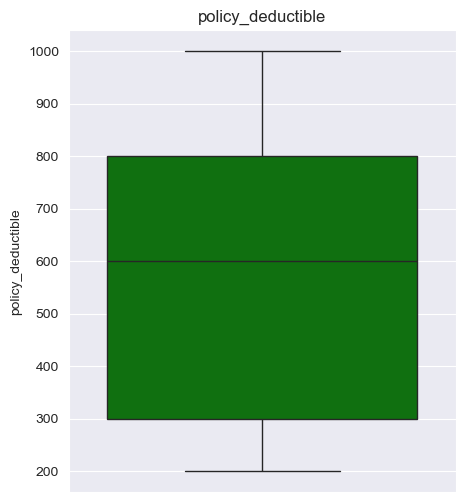

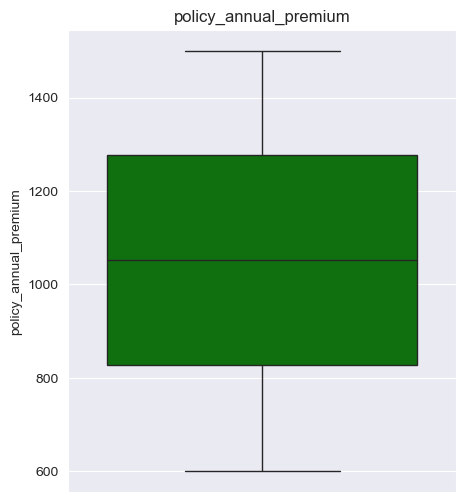

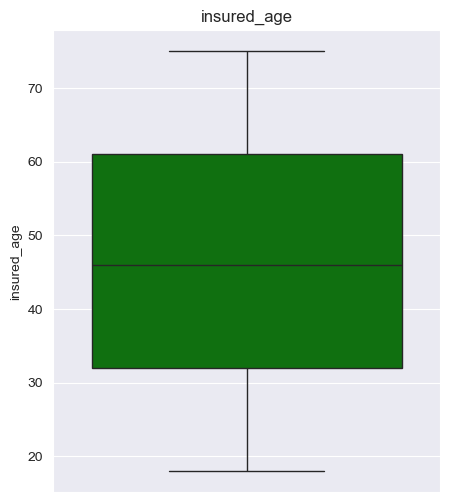

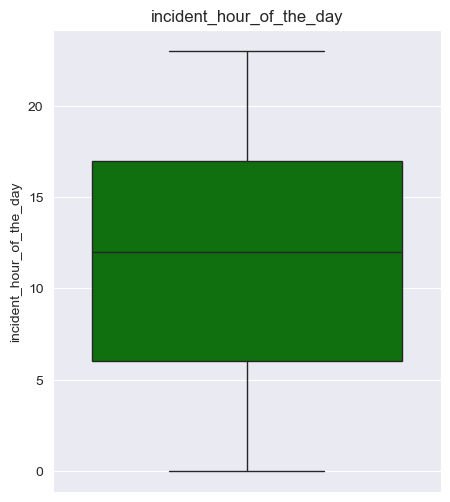

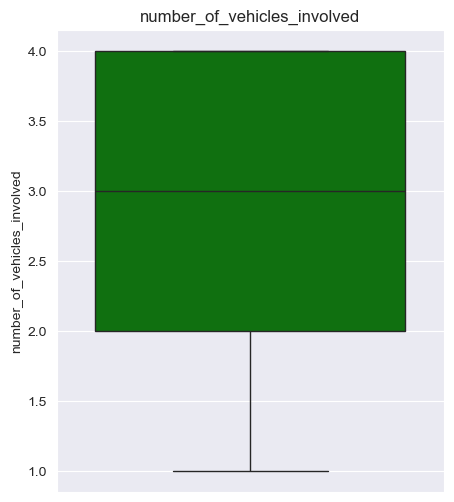

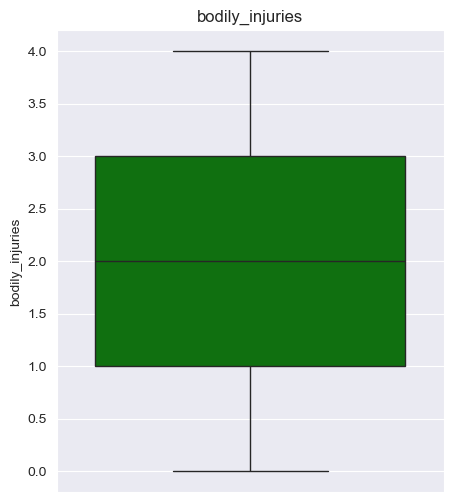

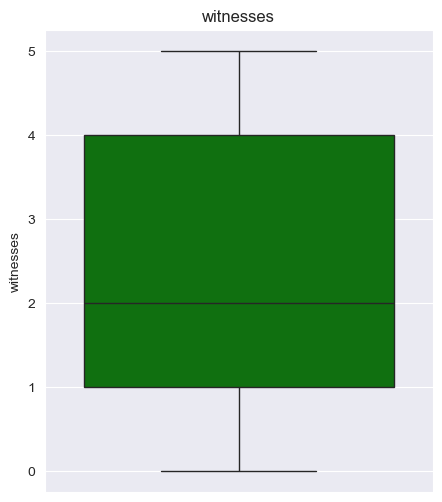

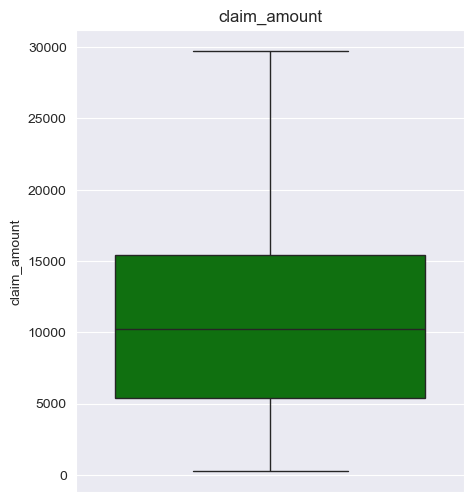

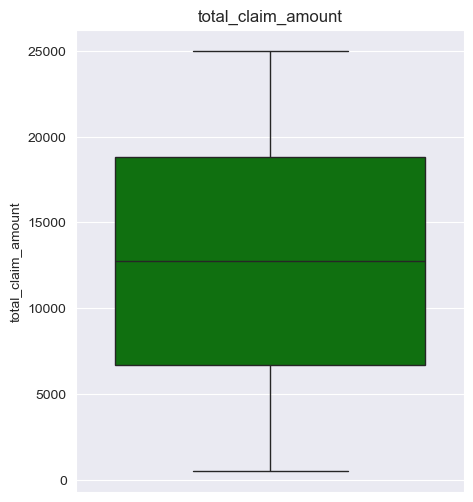

In [14]:
sb.set_style('darkgrid')
for x in insur_dataset.columns:
    if insur_dataset[x].dtype!= object:
        plt.figure(figsize= (5,6))
        sb.boxplot(y= insur_dataset[x], color= 'g')
        plt.title(x)
        plt.show()

#### Result- 
No outliers found

# EDA(Exploratory Data Analysis)

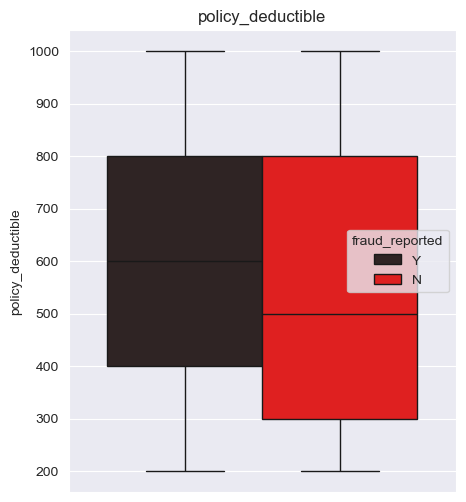

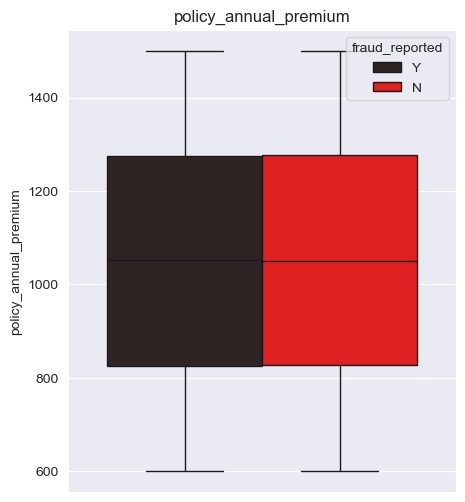

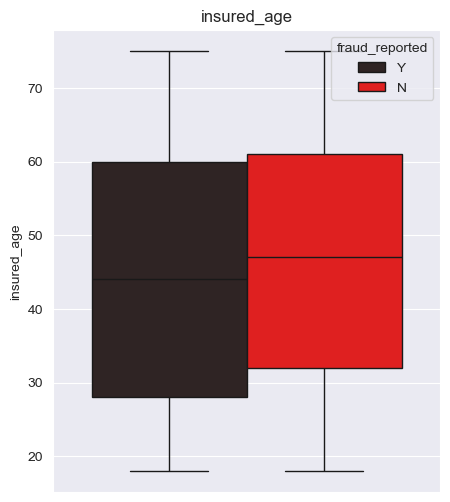

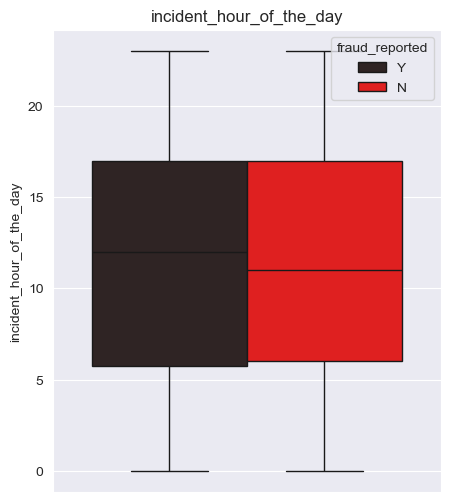

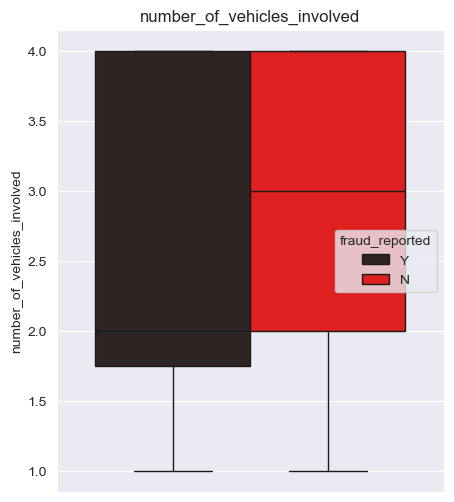

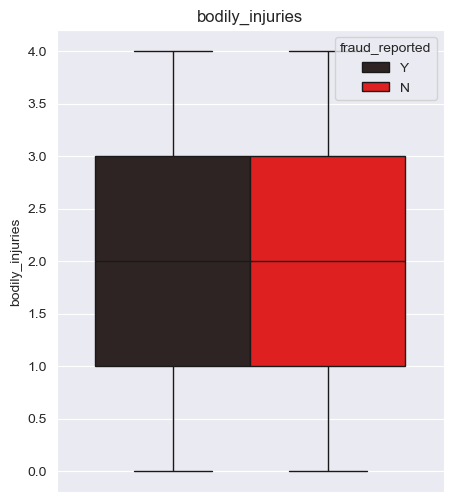

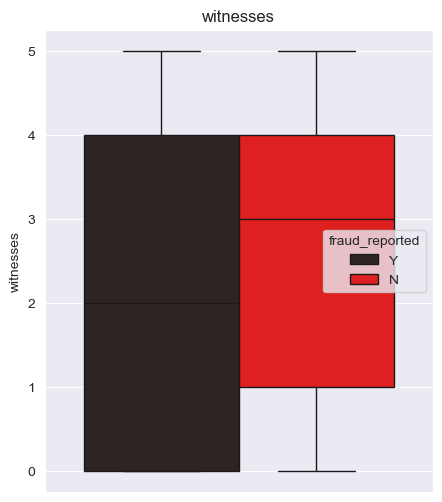

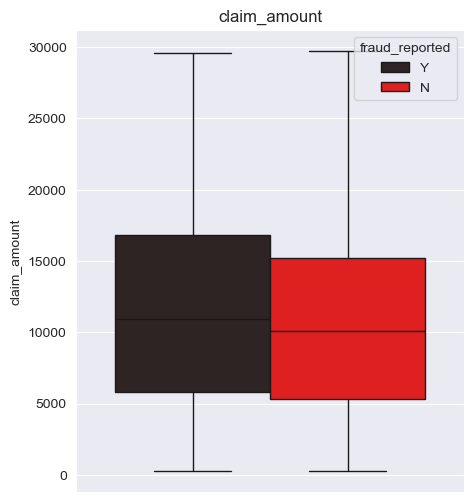

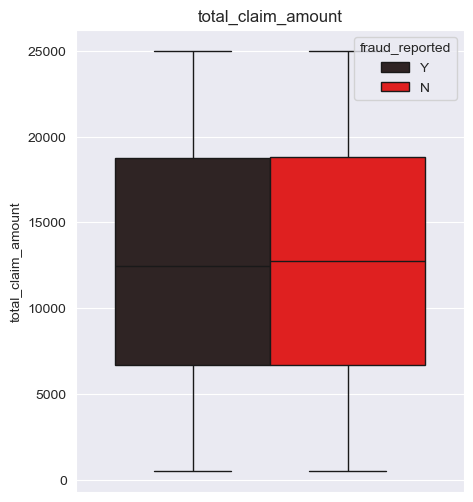

In [15]:
for y in insur_dataset.columns:
    if insur_dataset[y].dtype!= object:
        plt.figure(figsize= (5,6))
        sb.boxplot(y= insur_dataset[y], hue= insur_dataset['fraud_reported'], color= 'r')
        plt.title(y)
        plt.show()

# Obsevation-

* Insured have paid almost same policy_annual_premium for both the cases ('Y' and 'N')
* Young insured has higher chance of 'Y' fraud_reported
* Median of number_of_vehicles_involved in 'Y' case is 2.0 means higher risk of fraud with less no. of vehicles involved
* Median of both boxplot in bodily_injuries are same
* Lower the witness means greater the risk of fraud since the median of 'Y' is 2 which is lower than the 'N' case
* Median of 'Y' in claim_amount is slightly above the 'N' case
* Size of both boxplot is almost equal in total_claim_amount

In [16]:
insur_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   policy_id                    30000 non-null  object 
 1   policy_state                 30000 non-null  object 
 2   policy_deductible            30000 non-null  int64  
 3   policy_annual_premium        30000 non-null  float64
 4   insured_age                  30000 non-null  int64  
 5   insured_sex                  30000 non-null  object 
 6   insured_education_level      30000 non-null  object 
 7   insured_occupation           30000 non-null  object 
 8   insured_hobbies              30000 non-null  object 
 9   incident_date                30000 non-null  object 
 10  incident_type                30000 non-null  object 
 11  collision_type               30000 non-null  object 
 12  incident_severity            30000 non-null  object 
 13  authorities_cont

In [17]:
for z in insur_dataset.columns:
    if insur_dataset[z].dtype==object:
        if z not in ['incident_date','incident_city','policy_id']:
            print('***************')
            print(z)
            print(insur_dataset[z].unique())

***************
policy_state
['GA' 'PA' 'MI' 'CA' 'NC' 'FL' 'TX' 'NY' 'IL' 'OH']
***************
insured_sex
['OTHER' 'MALE' 'FEMALE']
***************
insured_education_level
['High School' 'College' 'PhD' 'Masters']
***************
insured_occupation
['Manager' 'Lawyer' 'Doctor' 'Teacher' 'Sales' 'Clerk' 'Technician'
 'Engineer']
***************
insured_hobbies
['reading' 'chess' 'yachting' 'camping' 'paintball' 'movies' 'hiking']
***************
incident_type
['Parked Car' 'Vehicle Theft' 'Single Vehicle Collision'
 'Multi-vehicle Collision']
***************
collision_type
['Front' 'Rear' 'Unknown' 'Side']
***************
incident_severity
['Total Loss' 'Minor Damage' 'Major Damage']
***************
authorities_contacted
['Fire' 'Police' 'Ambulance']
***************
incident_state
['MI' 'OH' 'NC' 'NY' 'FL' 'PA' 'IL' 'CA' 'TX' 'GA']
***************
police_report_available
['Yes' 'No']
***************
fraud_reported
['Y' 'N']


In [18]:
ctg_list= ['policy_state','insured_sex','insured_education_level','insured_occupation','insured_hobbies','incident_type','police_report_available']

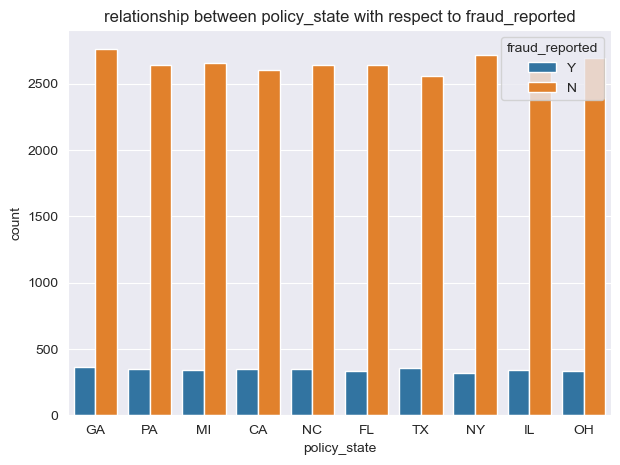

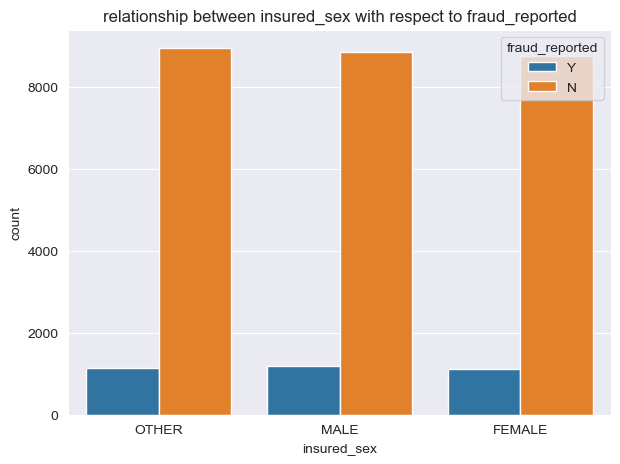

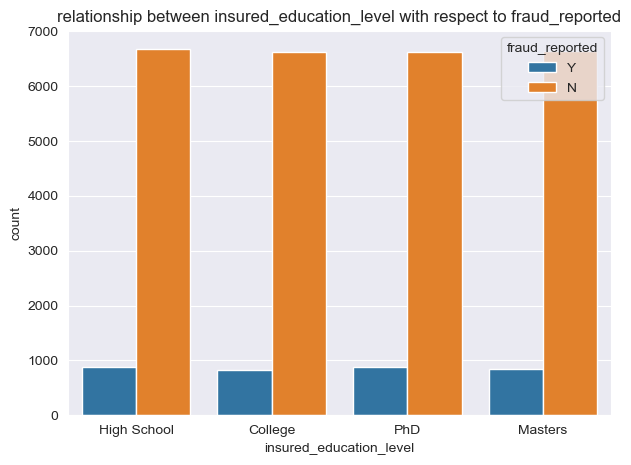

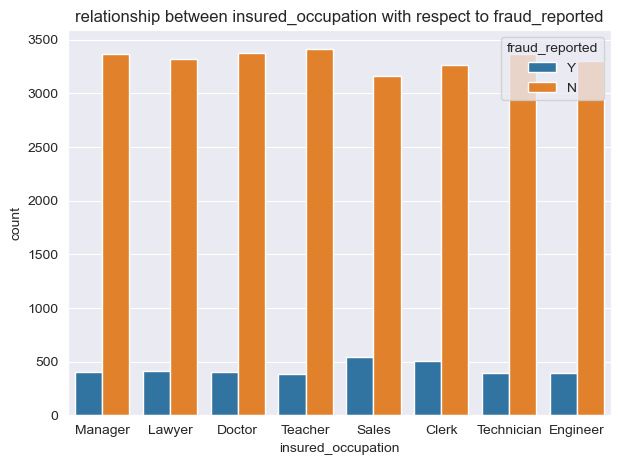

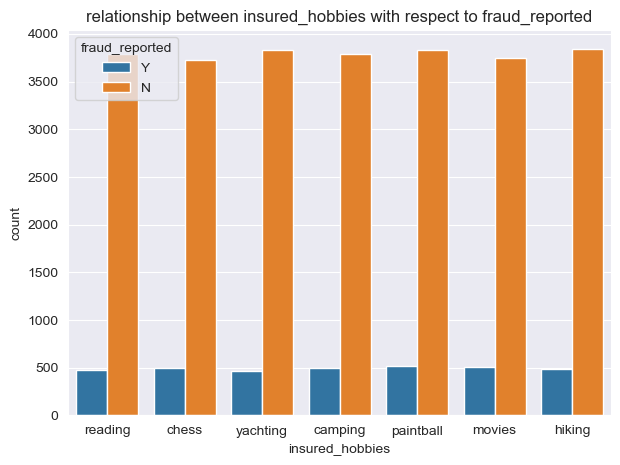

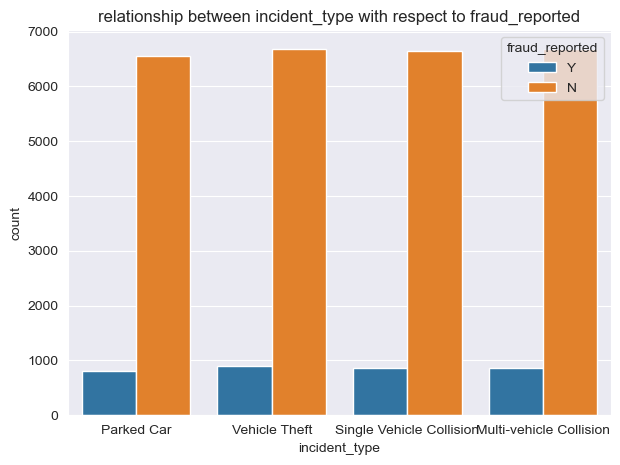

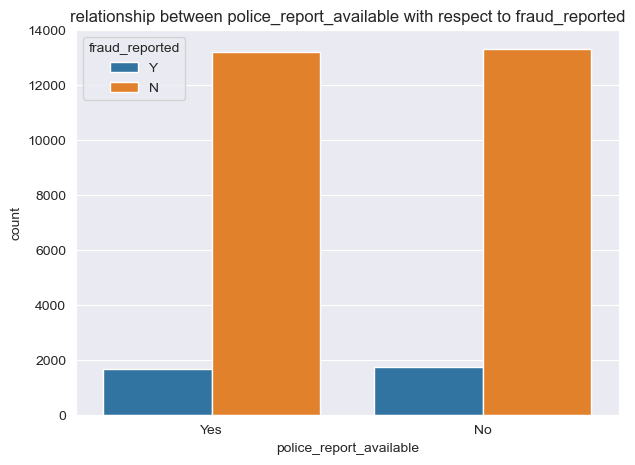

In [19]:
for c in ctg_list:
    plt.figure(figsize=(7,5))
    sb.countplot(x= insur_dataset[c], hue = insur_dataset['fraud_reported'])
    plt.xlabel(c)
    plt.title(f'relationship between {c} with respect to fraud_reported') 
    plt.show()

In [20]:
insur_dataset['fraud_reported'].value_counts()

fraud_reported
N    26560
Y     3440
Name: count, dtype: int64

###  Due to high imbalance in the fraud_reported varaible, there is a significant difference in the distribution of 'Y' and 'N' values in the plots

In [21]:
insur_dataset.skew(numeric_only= True) # We dont have to normalize the data since data is almost normal

policy_deductible              0.234975
policy_annual_premium         -0.002157
insured_age                    0.005484
incident_hour_of_the_day       0.000639
number_of_vehicles_involved   -0.008103
bodily_injuries                0.002897
witnesses                      0.004607
claim_amount                   0.442193
total_claim_amount             0.001891
dtype: float64

In [22]:
# creating new columns year,month and day from incident_date

insur_dataset['incident_date'] = pd.to_datetime(insur_dataset['incident_date'])

insur_dataset['incident_year'] = insur_dataset['incident_date'].dt.year
insur_dataset['incident_month'] = insur_dataset['incident_date'].dt.month
insur_dataset['incident_day']= insur_dataset['incident_date'].dt.day
insur_dataset['incident_week'] = insur_dataset['incident_date'].dt.dayofweek

In [23]:
date = ['incident_year','incident_month', 'incident_week']
for b in date:
    print('*********************')
    print(b)
    print(insur_dataset[b].value_counts())

*********************
incident_year
incident_year
2024    14986
2025    12906
2023     2108
Name: count, dtype: int64
*********************
incident_month
incident_month
1     2703
8     2596
10    2567
3     2560
7     2537
5     2534
11    2475
12    2442
4     2420
9     2415
6     2394
2     2357
Name: count, dtype: int64
*********************
incident_week
incident_week
2    4379
6    4322
1    4302
0    4299
4    4285
3    4229
5    4184
Name: count, dtype: int64


# Encoding

In [24]:
insur_dataset.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   policy_id                    30000 non-null  object        
 1   policy_state                 30000 non-null  object        
 2   policy_deductible            30000 non-null  int64         
 3   policy_annual_premium        30000 non-null  float64       
 4   insured_age                  30000 non-null  int64         
 5   insured_sex                  30000 non-null  object        
 6   insured_education_level      30000 non-null  object        
 7   insured_occupation           30000 non-null  object        
 8   insured_hobbies              30000 non-null  object        
 9   incident_date                30000 non-null  datetime64[ns]
 10  incident_type                30000 non-null  object        
 11  collision_type               30000 non-nu

In [25]:
le = LabelEncoder()
insur_dataset['fraud_reported']= le.fit_transform(insur_dataset['fraud_reported'])
insur_dataset['police_report_available'] = le.fit_transform(insur_dataset['police_report_available'])

In [26]:
# we dont have to encode every variable like 'policy_id' 'incident_city'
insur_dataset = insur_dataset.drop(['policy_id','incident_city'],axis=1)

In [27]:
insur_dataset = pd.get_dummies(insur_dataset, drop_first = True,dtype=int)

In [28]:
insur_dataset.shape

(30000, 62)

# using train_test_split


In [35]:
x= insur_dataset.drop(['fraud_reported','incident_date'], axis=1)
y = insur_dataset['fraud_reported']

In [36]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 60 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   policy_deductible                       30000 non-null  int64  
 1   policy_annual_premium                   30000 non-null  float64
 2   insured_age                             30000 non-null  int64  
 3   incident_hour_of_the_day                30000 non-null  int64  
 4   number_of_vehicles_involved             30000 non-null  int64  
 5   bodily_injuries                         30000 non-null  int64  
 6   witnesses                               30000 non-null  int64  
 7   police_report_available                 30000 non-null  int64  
 8   claim_amount                            30000 non-null  float64
 9   total_claim_amount                      30000 non-null  float64
 10  incident_year                           30000 non-null  in

In [37]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size= 0.20, random_state= 42)

In [38]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(24000, 60)
(6000, 60)
(24000,)
(6000,)


# Model Training

#### The target vairable fraud_reported is categorical(binary). Therefore this problem is a classification problem and classification algorithms will be used for modeling

In [39]:
# LogisticRegression
lr = LogisticRegression(class_weight= 'balanced') #using class_weight because fraud_reported vairable is imbalance

In [40]:
lr.fit(x_train,y_train)

LogisticRegression(class_weight='balanced')

In [41]:
y_pred = lr.predict(x_test)

In [42]:
(accuracy_score(y_test,y_pred))*100

59.483333333333334

In [47]:
(confusion_matrix(y_test,y_pred))

array([[3167, 2145],
       [ 286,  402]])

<Axes: >

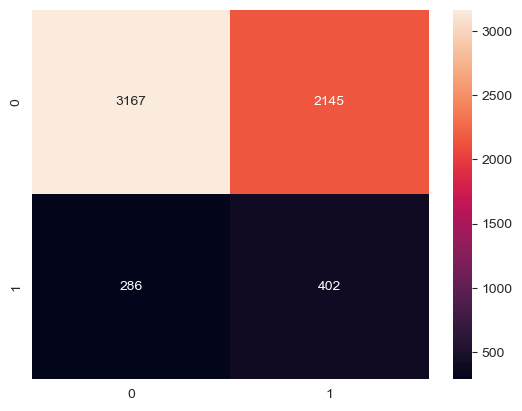

In [74]:
sb.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt= 'd')

In [64]:
#RandomForest
rf= RandomForestClassifier(class_weight= 'balanced')
rf.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced')

In [65]:
y_pred_rf= rf.predict(x_test)

In [66]:
accuracy_score(y_test,y_pred_rf)*100

88.53333333333333

In [67]:
confusion_matrix(y_test,y_pred_rf)

array([[5312,    0],
       [ 688,    0]])

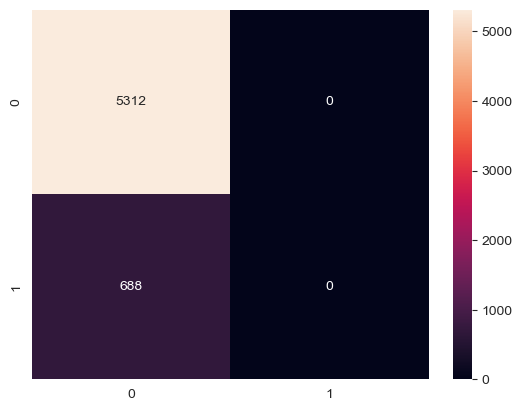

In [76]:
sb.heatmap(confusion_matrix(y_test,y_pred_rf), annot=True,fmt='d')
plt.show()

In [57]:
# DecisionTree
dt = DecisionTreeClassifier(class_weight= 'balanced')
dt.fit(x_train,y_train)

DecisionTreeClassifier(class_weight='balanced')

In [58]:
y_pred_dt= dt.predict(x_test)

In [60]:
accuracy_score(y_test,y_pred_dt)*100

81.21666666666667

In [68]:
confusion_matrix(y_test,y_pred_dt)

array([[4719,  593],
       [ 534,  154]])

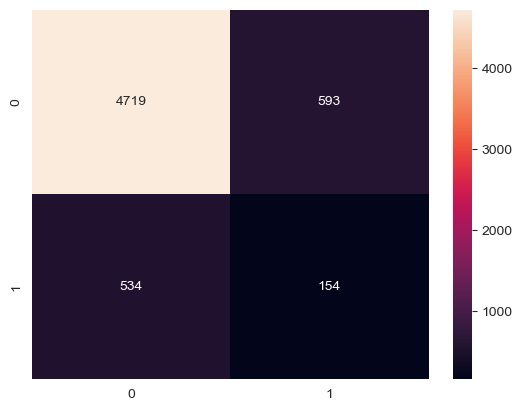

In [78]:
sb.heatmap(confusion_matrix(y_test,y_pred_dt),annot= True,fmt='d')
plt.show()

# Obsevation

Although Random Forest achieved higher accuracy, it failed to detect any fraud cases. Decision Tree, despite lower accuracy, was able to identify fraudulent instances. Therefore, Decision Tree is a more suitable model for this problem.

In [73]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      5312
           1       0.21      0.22      0.21       688

    accuracy                           0.81      6000
   macro avg       0.55      0.56      0.55      6000
weighted avg       0.82      0.81      0.82      6000



### conclusion

* This project aimed to detect fraudulent insurance claims using machine learning techniques. Due to class imbalance, accuracy alone was not a reliable metric. Among all models, Decision Tree performed better in identifying fraud cases, making it the most suitable model for this problem.